# 1. From a shape model to a dataset of eclipse function samples

An EclipseNET learns the **eclipse function** $F_\mathcal{B}(x, y, \hat{\mathbf{s}})$ of a body (Section 2.1 of the paper). Take the plane orthogonal to the Sun direction $\hat{\mathbf{s}}$: the body casts on it a shadow whose outline is the silhouette of the body seen from the Sun. $F_\mathcal{B}$ is the signed distance from that outline: negative in the shadow, positive outside, zero on the silhouette.

This notebook builds the ground truth the networks are trained on:

1. the silhouette of a shape model for one Sun direction;
2. the eclipse function on the plane;
3. the points at which it is sampled;
4. the full dataset, over many Sun directions;
5. panels A, B and C of Figure 2 of the paper.

In [1]:
import sys
sys.path.append('../')  # the repository root, where the eclipsenets package is

import numpy as np
import matplotlib.pyplot as plt

import eclipsenets as en

## The shape model

`load_body` returns the triangular mesh and the mascon model of one of the four bodies of the paper ("Bennu", "Itokawa", "67P", "Eros"). Lengths are in units of `L`, the extent of the mesh along x.

In [2]:
body = en.load_body("67P")
print(f"{body.name}: {len(body.mesh_points):,} vertices, {len(body.mesh_triangles):,} triangles, L = {body.L / 1e3:.4f} km")

Churyumov-Gerasimenko: 9,149 vertices, 18,294 triangles, L = 5.0026 km


## The silhouette for one Sun direction

`project_on_plane` gives the coordinates $(x, y)$ of a point on the plane orthogonal to the Sun direction. The silhouette is the union of the projected triangles of the mesh: `silhouette_polygon` returns it as a `shapely` polygon.

The silhouette has 335 vertices


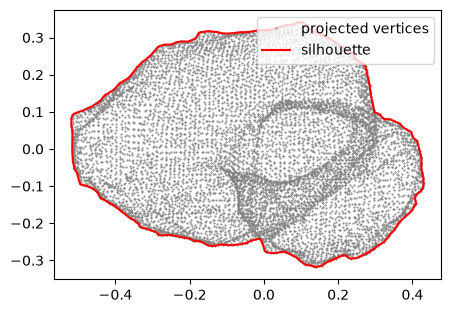

In [3]:
directions, az, el = en.fibonacci_sphere(10)
sun_direction = directions[-2]

projected = en.project_to_2d(body.mesh_points, sun_direction)
silhouette = en.silhouette_polygon(body.mesh_points, body.mesh_triangles, sun_direction)
border = en.silhouette_border(silhouette)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(projected[:, 0], projected[:, 1], '.', color='gray', markersize=1, label='projected vertices')
ax.plot(*silhouette.exterior.xy, 'r', linewidth=1.5, label='silhouette')
ax.set_aspect('equal')
ax.legend(loc='upper right')
print(f"The silhouette has {len(border)} vertices")

### Why not an alpha shape?

The datasets of the paper were built from the [alpha shape](https://en.wikipedia.org/wiki/Alpha_shape) of the projected vertices, also available here (`method="alpha"`). It needs a value of `alpha` tuned to each body: if it is too small the outline breaks up where the projected vertices are sparse, if it is too large the concavities get filled in. The union of the projected triangles has no parameter to tune, and is exact.

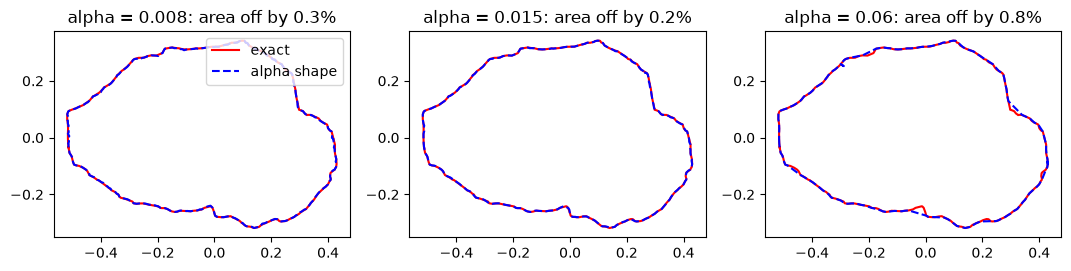

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, alpha in zip(axes, [0.008, 0.015, 0.06]):
    approximation = en.silhouette_polygon(body.mesh_points, body.mesh_triangles, sun_direction, method="alpha", alpha=alpha)
    ax.plot(*silhouette.exterior.xy, 'r', linewidth=1.5, label='exact')
    ax.plot(*approximation.exterior.xy, 'b--', linewidth=1.5, label='alpha shape')
    ax.set_title(f"alpha = {alpha}: area off by {100 * silhouette.symmetric_difference(approximation).area / silhouette.area:.1f}%")
    ax.set_aspect('equal')
axes[0].legend(loc='upper right');

## The eclipse function

`compute_eclipse_function` returns the signed distance of points of the plane from the border of the silhouette.

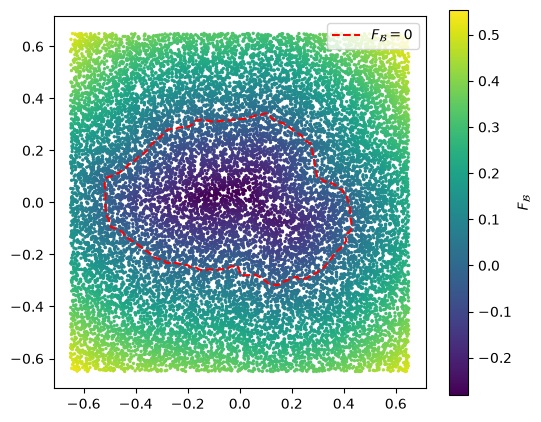

In [5]:
rng = np.random.default_rng(0)
points = rng.uniform(-0.65, 0.65, (20000, 2))
values = en.compute_eclipse_function(points, surface=silhouette)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(points[:, 0], points[:, 1], c=values, s=2)
ax.plot(*silhouette.exterior.xy, 'r--', label='$F_\\mathcal{B} = 0$')
fig.colorbar(scatter, label='$F_\\mathcal{B}$')
ax.set_aspect('equal')
ax.legend(loc='upper right');

The sign can be checked against ray tracing: a point is in eclipse if the ray leaving it towards the Sun hits the mesh (Möller-Trumbore test). `plane_to_3D` places the points of the plane behind the body.

In [6]:
v0, v1, v2 = body.triangle_vertices
positions = en.plane_to_3D(points[:2000, 0], points[:2000, 1], sun_direction, offset=-2.0)
eclipsed = np.array([en.is_eclipsed(position, sun_direction, v0, v1, v2) for position in positions])
print(f"Eclipse function and ray tracing agree on {np.mean(eclipsed == (values[:2000] < 0)):.1%} of {len(positions)} points")

Eclipse function and ray tracing agree on 100.0% of 2000 points


## Sampling one view

The network has to be most accurate next to the silhouette, where the eclipses start and end. `sample_view` therefore draws, for each Sun direction:

- 3,000 points around the border (clouds of 10 points around 300 points of the border);
- 1,000 points spread over a square that contains the silhouette;
- 500 points on the border, where the function is zero.

4500 samples


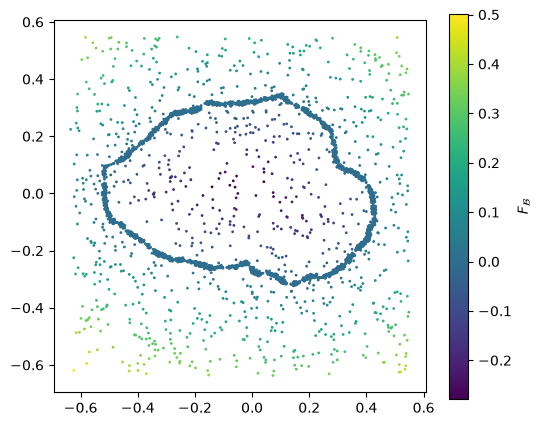

In [7]:
samples, sample_values = en.sample_view(silhouette, seed=0)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(samples[:, 0], samples[:, 1], c=sample_values, s=1)
fig.colorbar(scatter, label='$F_\\mathcal{B}$')
ax.set_aspect('equal')
print(f"{len(samples)} samples")

## The dataset

`generate_dataset` repeats this over Sun directions spread on a Fibonacci sphere. Each row of the dataset is

`[cos(az), sin(az), cos(el), sin(el), x, y, F]`

that is the six inputs of the network (the Sun direction, encoded through its azimuth and elevation, and the point on the plane) followed by the target.

The datasets of the repository have 500 directions for training and 200 for validation, which takes a few minutes per body to generate. With about 4,500 samples per direction, they hold 2.3 million training samples and 0.9 million validation samples. Here are 20 directions, as an example:

In [8]:
data = en.generate_dataset(body.mesh_points, body.mesh_triangles, n_views=20, cull_backfaces=True, seed=0, progress=False)
print(f"Dataset of shape {data.shape}: {np.mean(data[:, -1] < 0):.0%} of the samples are in eclipse")

Dataset of shape (90000, 7): 41% of the samples are in eclipse


The full datasets are generated from the command line:

```
python scripts/generate_dataset.py --body 67P --views 500 --output datasets/generated/chu-ger_train.pk
python scripts/generate_dataset.py --body 67P --views 200 --output datasets/generated/chu-ger_valid.pk
```

The datasets of the repository are in `datasets/`, stored with git lfs (`git lfs pull` downloads them). `en.published_dataset_path(body, split)` gives the file of each body and `en.load_dataset` reads it:

In [9]:
published = en.load_dataset(en.published_dataset_path("67P", "train"))
print(f"Training set of 67P: {published.shape[0]:,} samples from {len(np.unique(published[:, :4], axis=0))} Sun directions")

Training set of 67P: 2,349,414 samples from 500 Sun directions


## Figure 2 of the paper, panels A to C

For the four bodies: the shape model (A), the eclipse function for one Sun direction (B) and its samples (C).

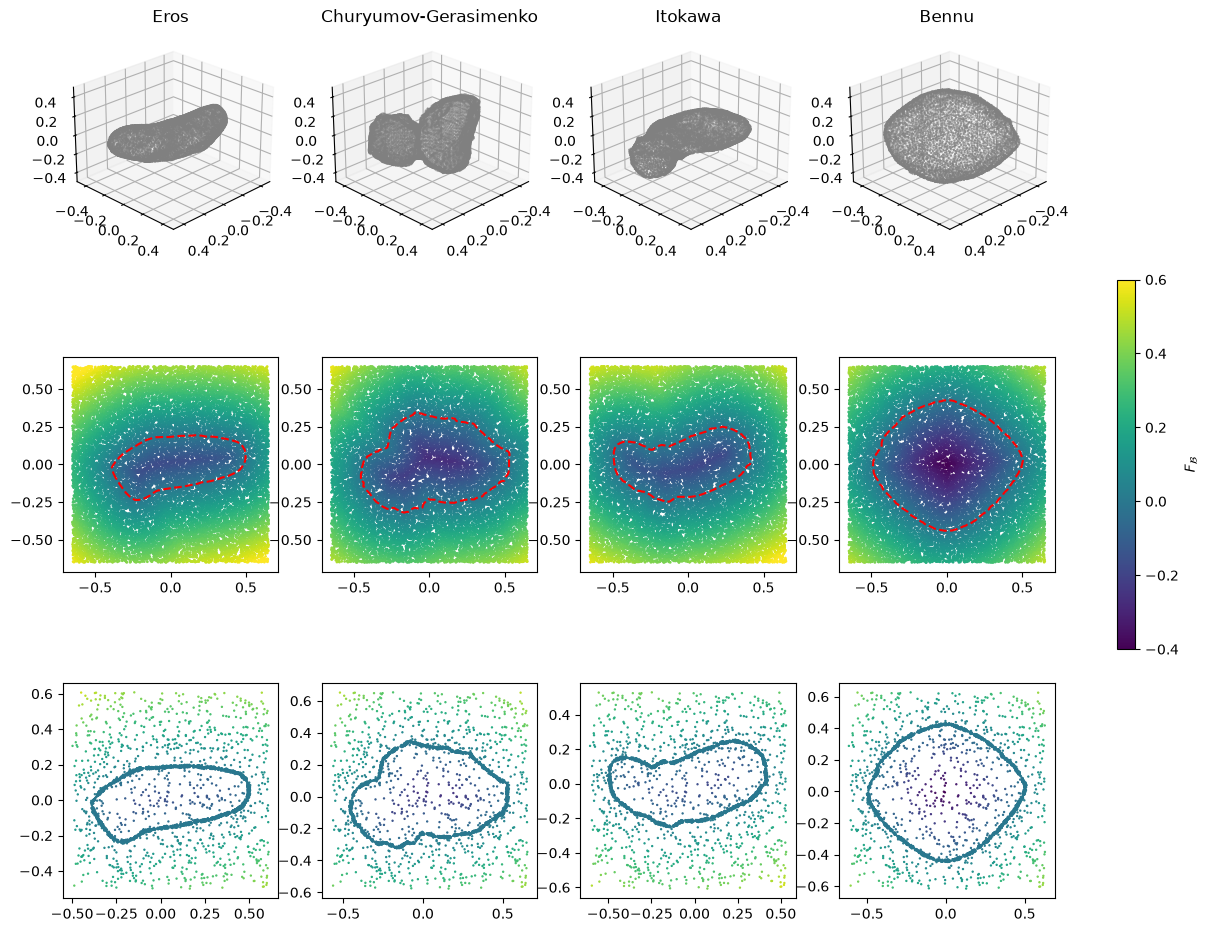

In [10]:
names = ["Eros", "67P", "Itokawa", "Bennu"]
sun_direction = en.sph2cart(az=120., el=75.)

fig = plt.figure(figsize=(16, 12))
for column, name in enumerate(names):
    body = en.load_body(name)
    silhouette = en.silhouette_polygon(body.mesh_points, body.mesh_triangles, sun_direction)

    # A) shape model
    ax = fig.add_subplot(3, 4, column + 1, projection='3d')
    en.plot_mesh_vertices(body.mesh_points, 0.5, ax=ax, plot_ref=False, axis_off=False, s=0.2, c='gray')
    ax.view_init(elev=25., azim=45.)
    ax.set_title(body.name)

    # B) eclipse function
    ax = fig.add_subplot(3, 4, column + 5)
    points = rng.uniform(-0.65, 0.65, (20000, 2))
    scatter = ax.scatter(points[:, 0], points[:, 1], c=en.compute_eclipse_function(points, surface=silhouette),
                         s=1, vmin=-0.4, vmax=0.6)
    ax.plot(*silhouette.exterior.xy, 'r--')
    ax.set_aspect('equal')

    # C) samples
    ax = fig.add_subplot(3, 4, column + 9)
    samples, sample_values = en.sample_view(silhouette, seed=0)
    ax.scatter(samples[:, 0], samples[:, 1], c=sample_values, s=0.5, vmin=-0.4, vmax=0.6)
    ax.set_aspect('equal')
fig.colorbar(scatter, ax=fig.axes, shrink=0.4, label='$F_\\mathcal{B}$');